# Assignment 3.2 - Deep Q-Learning with Policy and Target network for Frozen-walk game

This assignment aims at familiarizing you with training, validating and testing a reinforncement learning agent using Deep Q-Learning with Policy and Target network for Frozen-walk game. Here are the requirements of the assignment:

1.  **(4 points) Coding Tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Initiate a Frozen lake environment and an agent.  
    1.2 *(1 point)* Train the agent using <b>Deep Q-Learning with Policy and Target network</b>. You can base on the demo code to construct the target network as a copy of the policy network and periodically synchronized with the policy network.  
    1.3 *(1 point)* Print out the optimal policy, i.e., what is the best action at a stage.  
    1.4 *(1 point)* Compare and discuss the performance of the two approaches (1) one policy network and (2) one policy network and one target network, especially in regards of convergence stability.  

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake.

![Frozen walk](https://gymnasium.farama.org/_images/frozen_lake.gif)

More details can be found at https://gymnasium.farama.org/environments/toy_text/frozen_lake/.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment3-2-notebook.ipynb: Jupyter notebook containing source code.

### Evaluation {-}
Assignment evaluation will be conducted on how you accomplish the assignment requirements. In addition, your code should conform to a Python coding convention such as PEP-8.

### Deadline {-}
Please visit Canvas for details.

### Install libraries and initiate a frozen lake map

In [1]:
# Install gymnasium game environment
!pip install gymnasium
!pip install "gymnasium[toy-text]"

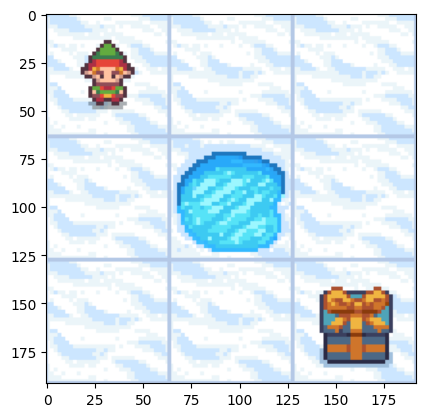

In [2]:
### Please do not change this code

# Load libraries
import gymnasium as gym
import numpy as np
import tensorflow as tf
import random
from collections import deque
import matplotlib.pyplot as plt

# Define environment map
custom_map = [
    'SFF',
    'FHF',
    'FFG'
]

# Initialize the environment
env = gym.make('FrozenLake-v1', desc=custom_map, is_slippery=False, render_mode='rgb_array')
state_size = env.observation_space.n
action_size = env.action_space.n

env.reset()
plt.imshow(env.render())

### Solution

In [3]:
# Your code goes here
# 1.1
# Initiate a Frozen lake environment and an agent. 
# Define Deep Q-Network (DQN)
class DQN(tf.keras.Model):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = tf.keras.layers.Dense(32, activation='relu')
        self.fc2 = tf.keras.layers.Dense(32, activation='relu')
        self.fc3 = tf.keras.layers.Dense(action_size, activation=None)

    def call(self, state):
        x = self.fc1(state)
        x = self.fc2(x)
        return self.fc3(x)

# Define Agent Class
class Agent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=1000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.learning_rate = 0.01
        self.batch_size = 64
        self.update_target_every = 10
        self.target_update_counter = 0

        self.policy_net = DQN(state_size, action_size)
        self.target_net = DQN(state_size, action_size)
        self.target_net.set_weights(self.policy_net.get_weights())
        self.target_net.trainable = False
        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        self.loss_function = tf.keras.losses.MeanSquaredError()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return env.action_space.sample()
        state_tensor = tf.one_hot([state], self.state_size)
        return tf.argmax(self.policy_net(state_tensor), axis=1).numpy()[0]

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = tf.one_hot(states, self.state_size)
        next_states = tf.one_hot(next_states, self.state_size)
        actions = tf.convert_to_tensor(actions, dtype=tf.int32)
        rewards = tf.convert_to_tensor(rewards, dtype=tf.float32)
        dones = tf.convert_to_tensor(dones, dtype=tf.float32)

        with tf.GradientTape() as tape:
            q_values = tf.reduce_sum(self.policy_net(states) * tf.one_hot(actions, self.action_size), axis=1)
            next_q_values = tf.reduce_max(self.target_net(next_states), axis=1)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))
            loss = self.loss_function(target_q_values, q_values)

        grads = tape.gradient(loss, self.policy_net.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.policy_net.trainable_variables))

        self.target_update_counter += 1
        if self.target_update_counter % self.update_target_every == 0:
            self.target_net.set_weights(self.policy_net.get_weights())

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [8]:
# Your code goes here
# 1.2
# Initialize Agent
agent = Agent(state_size, action_size)
episodes = 1000

# Training loop
for episode in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    steps = 0
    
    while not done:
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        agent.replay()
        steps += 1
    
    agent.update_epsilon()
    if episode % 50 == 0:
        print(f"Episode {episode}, Steps: {steps}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.3f}")


Episode 0, Steps: 3, Total Reward: 0.0, Epsilon: 0.995
Episode 50, Steps: 4, Total Reward: 0.0, Epsilon: 0.774
Episode 100, Steps: 21, Total Reward: 0.0, Epsilon: 0.603
Episode 150, Steps: 18, Total Reward: 0.0, Epsilon: 0.469
Episode 200, Steps: 31, Total Reward: 0.0, Epsilon: 0.365
Episode 250, Steps: 23, Total Reward: 1.0, Epsilon: 0.284
Episode 300, Steps: 5, Total Reward: 1.0, Epsilon: 0.221
Episode 350, Steps: 4, Total Reward: 1.0, Epsilon: 0.172
Episode 400, Steps: 21, Total Reward: 1.0, Epsilon: 0.134
Episode 450, Steps: 32, Total Reward: 0.0, Epsilon: 0.104
Episode 500, Steps: 76, Total Reward: 0.0, Epsilon: 0.081
Episode 550, Steps: 100, Total Reward: 0.0, Epsilon: 0.063
Episode 600, Steps: 73, Total Reward: 0.0, Epsilon: 0.049
Episode 650, Steps: 4, Total Reward: 1.0, Epsilon: 0.038
Episode 700, Steps: 4, Total Reward: 1.0, Epsilon: 0.030
Episode 750, Steps: 9, Total Reward: 1.0, Epsilon: 0.023
Episode 800, Steps: 4, Total Reward: 1.0, Epsilon: 0.018
Episode 850, Steps: 5, T

In [ ]:
# Your code goes here
# 1.3
# Mapping actions to directions
action_map = {0: 'L', 1: 'D', 2: 'R', 3: 'U'}

# Get optimal policy in direction format
optimal_policy = []
for state in range(state_size):
    state_tensor = tf.one_hot([state], state_size)
    action = tf.argmax(agent.policy_net(state_tensor), axis=1).numpy()[0]
    optimal_policy.append(action_map[action])

# Print policy in 3x3 format
print("Optimal Policy Grid:")
for i in range(3):  # 3 rows
    print(optimal_policy[i * 3:(i + 1) * 3])  # 3 columns per row


Optimal Policy Grid:
['D', 'R', 'D']
['D', 'D', 'D']
['R', 'R', 'D']


: 

In [ ]:
# Your code goes here
# 1.4
# Compare and discuss the result and the performance of the one policy network with one policy and one target network
# Both models reduce ε (exploration rate) over time. But the policy + target network configuration achieves a better epsilon decay, meaning it learns more efficiently.
# The addition of a target network stabilizes training by preventing rapid policy oscillations.
# The policy network alone shows more variance in step counts, indicating less stable convergence.
# The policy + target network setup learns more effectively and stabilizes faster around episode 650.